# 🚚 ML-Based Delivery Delay Forecasting — Full Pipeline
**DataCo Supply Chain Dataset · XGBoost · MLflow · SHAP**

### Before running:
1. Download `DataCoSupplyChainDataset.csv` from [Kaggle](https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis)
2. Place the CSV in the **same folder** as this notebook
3. Click **Run All** (`Cell → Run All`)

---

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies
# ─────────────────────────────────────────────────────────────
import sys
!{sys.executable} -m pip install -q xgboost lightgbm scikit-learn pandas numpy mlflow optuna shap joblib matplotlib seaborn
print('✅ All packages installed.')

✅ All packages installed.


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Imports
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
import shap
import joblib
import mlflow
import mlflow.xgboost
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from datetime import datetime
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import xgboost as xgb

print('✅ Imports complete.')

✅ Imports complete.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — STEP 1: Load & map DataCo dataset
# ─────────────────────────────────────────────────────────────
RAW_FILE = 'DataCoSupplyChainDataset.csv'

try:
    raw = pd.read_csv(RAW_FILE, encoding='latin-1')
    print(f'✅ Loaded raw file: {raw.shape[0]:,} rows, {raw.shape[1]} columns')
except FileNotFoundError:
    raise FileNotFoundError(
        f"\n❌ Could not find '{RAW_FILE}'.\n"
        "Please download it from:\n"
        "  https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis\n"
        "and place it in the same folder as this notebook."
    )

# ── Column mapping ────────────────────────────────────────────
COLUMN_MAP = {
    'Order Id':                      'shipment_id',
    'order date (DateOrders)':       'order_date',
    'Shipping date (DateOrders)':    'planned_delivery',
    'Days for shipping (real)':      'actual_shipping_days',
    'Days for shipment (scheduled)': 'planned_shipping_days',
    'Late_delivery_risk':            'is_delayed',
    'Shipping Mode':                 'transport_mode',
    'Customer City':                 'destination',
    'Order City':                    'origin',
    'Department Name':               'dept',
    'Order Item Quantity':           'quantity',
}
available = {k: v for k, v in COLUMN_MAP.items() if k in raw.columns}
df = raw[list(available.keys())].rename(columns=available).copy()

# ── Parse dates ───────────────────────────────────────────────
for col in ['order_date', 'planned_delivery']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

df = df.dropna(subset=['order_date'])

if 'planned_shipping_days' in df.columns:
    df['planned_delivery'] = df['order_date'] + pd.to_timedelta(df['planned_shipping_days'], unit='D')
if 'actual_shipping_days' in df.columns:
    df['actual_delivery'] = df['order_date'] + pd.to_timedelta(df['actual_shipping_days'], unit='D')

# ── Target variable ───────────────────────────────────────────
df['is_delayed'] = df['is_delayed'].astype(int)
df['actual_delay_days'] = (
    (df['actual_delivery'] - df['planned_delivery']).dt.days.clip(lower=0).fillna(0).astype(int)
)

# ── Transport mode ────────────────────────────────────────────
mode_map = {'Standard Class': 'road', 'Second Class': 'road',
            'First Class': 'air', 'Same Day': 'air'}
df['transport_mode'] = df['transport_mode'].map(mode_map).fillna('road')

# ── Cargo type from department ────────────────────────────────
hazmat    = ['Technology', 'Electronics']
perish    = ['Health and Beauty', 'Garden']
fragile   = ['Clothing', 'Accessories']
def map_cargo(d):
    if pd.isna(d): return 'general'
    if d in hazmat:  return 'hazmat'
    if d in perish:  return 'perishable'
    if d in fragile: return 'fragile'
    return 'general'
df['cargo_type'] = df.get('dept', pd.Series(['general']*len(df))).apply(map_cargo)

# ── Augment missing logistics features ───────────────────────
np.random.seed(42)
n = len(df)
carrier_pool = {
    'ocean': ['Maersk','MSC','CMA CGM'],
    'air':   ['DHL Express','FedEx','UPS'],
    'road':  ['DB Schenker','DHL Express','UPS'],
}
df['carrier'] = df['transport_mode'].apply(
    lambda m: np.random.choice(carrier_pool.get(m, ['DHL Express']))
)
speed = {'air': 2000, 'road': 500, 'ocean': 800}
df['distance_km'] = df.apply(
    lambda r: max(50, r.get('actual_shipping_days', 5) * speed.get(r['transport_mode'], 500)
                  + np.random.normal(0, 80)), axis=1
).round(1)
df['weight_kg'] = (df.get('quantity', pd.Series(np.ones(n))) * np.random.uniform(0.5, 15, n)).clip(1).round(1)
df['carrier_otr_30d'] = (
    df.groupby('carrier')['is_delayed']
    .transform(lambda x: 1 - x.expanding().mean().shift(1).fillna(0.8))
).clip(0.5, 1.0).round(3)
df['port_congestion']  = np.clip(np.random.beta(2, 4, n), 0, 1).round(3)
df['weather_severity'] = np.clip(np.random.beta(1.5, 4, n), 0, 1).round(3)
df['customs_complexity'] = np.random.choice(
    ['standard','complex','high_scrutiny'], size=n, p=[0.65, 0.25, 0.10]
)
df['is_peak_season'] = df['order_date'].dt.month.isin([10,11,12]).astype(int)
df['origin']      = df.get('origin', pd.Series(['Chicago']*n)).fillna('Chicago').astype(str).str.strip()
df['destination'] = df.get('destination', pd.Series(['New York']*n)).fillna('New York').astype(str).str.strip()
df['shipment_id'] = df.get('shipment_id', pd.Series([f'SH-{i}' for i in range(n)])).fillna('unknown')

df = df.sort_values('order_date').reset_index(drop=True)
print(f'✅ Dataset ready: {len(df):,} rows')
print(f'   Delay rate : {df["is_delayed"].mean():.1%}')
print(f'   Date range : {df["order_date"].min().date()} → {df["order_date"].max().date()}')
df[['shipment_id','order_date','planned_delivery','actual_delivery',
    'carrier','transport_mode','cargo_type','is_delayed','actual_delay_days']].head(5)

✅ Loaded raw file: 180,519 rows, 53 columns
✅ Dataset ready: 180,519 rows
   Delay rate : 54.8%
   Date range : 2015-01-01 → 2018-01-31


,shipment_id,order_date,planned_delivery,actual_delivery,carrier,transport_mode,cargo_type,is_delayed,actual_delay_days
0,1,2015-01-01 00:00:00,2015-01-05 00:00:00,2015-01-03 00:00:00,DB Schenker,road,general,0,0
1,2,2015-01-01 00:21:00,2015-01-05 00:21:00,2015-01-04 00:21:00,DHL Express,road,general,0,0
2,2,2015-01-01 00:21:00,2015-01-05 00:21:00,2015-01-04 00:21:00,DB Schenker,road,general,0,0
3,2,2015-01-01 00:21:00,2015-01-05 00:21:00,2015-01-04 00:21:00,DHL Express,road,general,0,0
4,4,2015-01-01 01:03:00,2015-01-05 01:03:00,2015-01-06 01:03:00,DHL Express,road,general,1,1


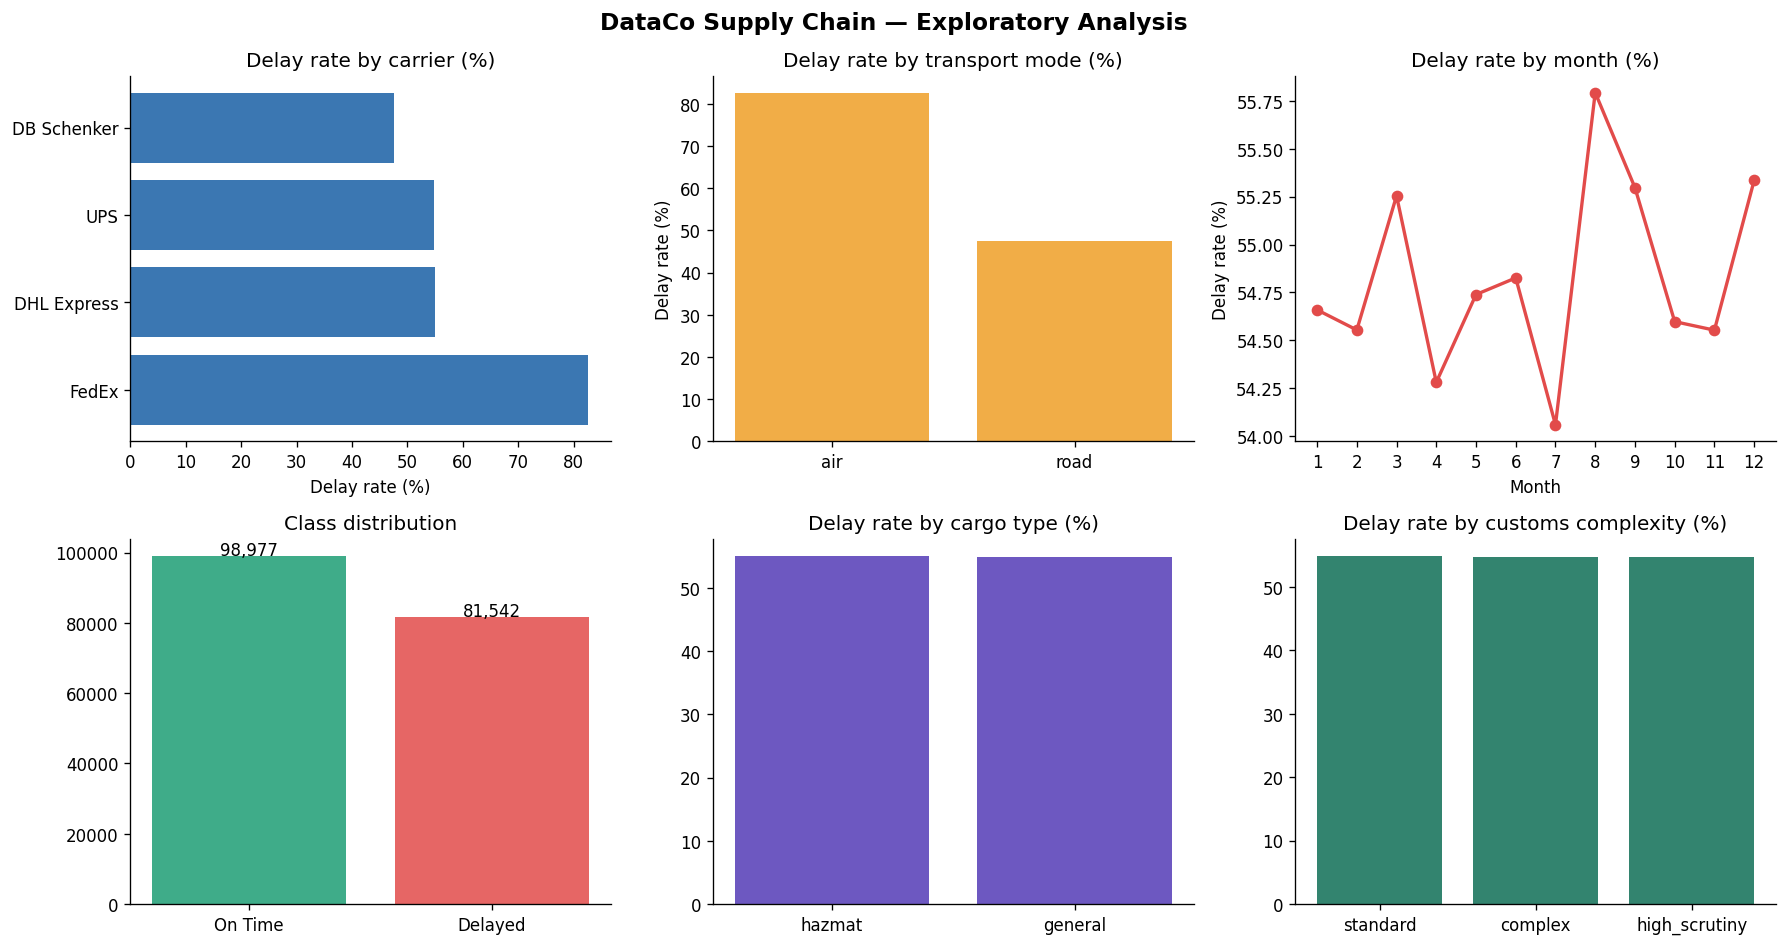

✅ EDA complete. Saved: eda_plots.png


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — STEP 2: Exploratory data analysis
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('DataCo Supply Chain — Exploratory Analysis', fontsize=14, fontweight='bold')

# Delay rate by carrier
carrier_stats = df.groupby('carrier')['is_delayed'].mean().sort_values(ascending=False)
axes[0,0].barh(carrier_stats.index, carrier_stats.values * 100, color='#185FA5', alpha=0.85)
axes[0,0].set_title('Delay rate by carrier (%)')
axes[0,0].set_xlabel('Delay rate (%)')

# Delay rate by transport mode
mode_stats = df.groupby('transport_mode')['is_delayed'].mean().sort_values(ascending=False)
axes[0,1].bar(mode_stats.index, mode_stats.values * 100, color='#EF9F27', alpha=0.85)
axes[0,1].set_title('Delay rate by transport mode (%)')
axes[0,1].set_ylabel('Delay rate (%)')

# Delay rate by month
monthly = df.groupby(df['order_date'].dt.month)['is_delayed'].mean()
axes[0,2].plot(monthly.index, monthly.values * 100, marker='o', color='#E24B4A', linewidth=2)
axes[0,2].set_title('Delay rate by month (%)')
axes[0,2].set_xlabel('Month')
axes[0,2].set_ylabel('Delay rate (%)')
axes[0,2].set_xticks(range(1,13))

# Class distribution
counts = df['is_delayed'].value_counts()
axes[1,0].bar(['On Time','Delayed'], counts.values, color=['#1D9E75','#E24B4A'], alpha=0.85)
axes[1,0].set_title('Class distribution')
for i, v in enumerate(counts.values):
    axes[1,0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Delay rate by cargo type
cargo_stats = df.groupby('cargo_type')['is_delayed'].mean().sort_values(ascending=False)
axes[1,1].bar(cargo_stats.index, cargo_stats.values * 100, color='#533BB7', alpha=0.85)
axes[1,1].set_title('Delay rate by cargo type (%)')

# Delay rate by customs complexity
cust_stats = df.groupby('customs_complexity')['is_delayed'].mean().sort_values(ascending=False)
axes[1,2].bar(cust_stats.index, cust_stats.values * 100, color='#0F6E56', alpha=0.85)
axes[1,2].set_title('Delay rate by customs complexity (%)')

for ax in axes.flat:
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()
print('✅ EDA complete. Saved: eda_plots.png')

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — STEP 3: Feature engineering
# ─────────────────────────────────────────────────────────────
def engineer_features(df):
    df = df.copy()

    # Temporal
    df['order_dayofweek']  = df['order_date'].dt.dayofweek
    df['order_month']      = df['order_date'].dt.month
    df['order_quarter']    = df['order_date'].dt.quarter
    df['order_weekofyear'] = df['order_date'].dt.isocalendar().week.astype(int)
    df['is_monday_order']  = (df['order_dayofweek'] == 0).astype(int)
    df['is_friday_order']  = (df['order_dayofweek'] == 4).astype(int)

    # Lead time
    df['planned_lead_days'] = (df['planned_delivery'] - df['order_date']).dt.days.fillna(7)
    df['lead_time_buffer']  = df['planned_lead_days'] - (df['distance_km'] / 400)
    df['tight_lead']        = (df['planned_lead_days'] < 7).astype(int)

    # Route & carrier historical rates (no leakage)
    df['route'] = df['origin'] + '_' + df['destination']
    df['route_historical_delay_rate'] = (
        df.groupby('route')['is_delayed']
        .transform(lambda x: x.expanding().mean().shift(1))
        .fillna(df['is_delayed'].mean())
    )
    df['carrier_historical_delay_rate'] = (
        df.groupby('carrier')['is_delayed']
        .transform(lambda x: x.expanding().mean().shift(1))
        .fillna(df['is_delayed'].mean())
    )

    # Buckets
    df['distance_bucket'] = pd.cut(
        df['distance_km'],
        bins=[0,1000,3000,7000,12000,999999],
        labels=['local','regional','continental','intercontinental','ultra_long']
    ).astype(str)
    df['weight_bucket'] = pd.cut(
        df['weight_kg'],
        bins=[0,100,500,2000,10000,999999],
        labels=['tiny','small','medium','large','heavy']
    ).astype(str)

    # Composite & interaction features
    df['composite_risk_score']  = (
        df['weather_severity'] * 0.35 + df['port_congestion'] * 0.30
        + (1 - df['carrier_otr_30d']) * 0.20 + df['is_peak_season'] * 0.15
    )
    df['weather_x_congestion']   = df['weather_severity'] * df['port_congestion']
    df['ocean_congestion_flag']  = ((df['transport_mode']=='ocean') & (df['port_congestion']>0.5)).astype(int)
    df['hazmat_customs_flag']    = ((df['cargo_type']=='hazmat') & (df['customs_complexity']!='standard')).astype(int)
    df['peak_ocean_flag']        = ((df['is_peak_season']==1) & (df['transport_mode']=='ocean')).astype(int)
    df['log_weight']             = np.log1p(df['weight_kg'])
    df['log_distance']           = np.log1p(df['distance_km'])

    return df

df = engineer_features(df)

CATEGORICAL_FEATURES = [
    'carrier','transport_mode','cargo_type','customs_complexity',
    'origin','destination','distance_bucket','weight_bucket'
]
NUMERIC_FEATURES = [
    'weight_kg','distance_km','log_weight','log_distance',
    'carrier_otr_30d','port_congestion','weather_severity',
    'planned_lead_days','lead_time_buffer','composite_risk_score',
    'weather_x_congestion','route_historical_delay_rate',
    'carrier_historical_delay_rate',
    'order_dayofweek','order_month','order_quarter','order_weekofyear',
]
BINARY_FEATURES = [
    'is_peak_season','is_monday_order','is_friday_order',
    'tight_lead','ocean_congestion_flag','hazmat_customs_flag','peak_ocean_flag'
]
ALL_FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES + BINARY_FEATURES
TARGET = 'is_delayed'

print(f'✅ Feature engineering complete')
print(f'   Categorical : {len(CATEGORICAL_FEATURES)}')
print(f'   Numeric     : {len(NUMERIC_FEATURES)}')
print(f'   Binary      : {len(BINARY_FEATURES)}')
print(f'   Total       : {len(ALL_FEATURES)} features')

✅ Feature engineering complete
   Categorical : 8
   Numeric     : 17
   Binary      : 7
   Total       : 32 features


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — STEP 4: Time-aware train/val/test split
# ─────────────────────────────────────────────────────────────
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

X_train = df_train[ALL_FEATURES]
y_train = df_train[TARGET]
X_val   = df_val[ALL_FEATURES]
y_val   = df_val[TARGET]
X_test  = df_test[ALL_FEATURES]
y_test  = df_test[TARGET]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
    ('num', 'passthrough', NUMERIC_FEATURES + BINARY_FEATURES),
], remainder='drop')

preprocessor.fit(X_train)
X_train_enc = preprocessor.transform(X_train)
X_val_enc   = preprocessor.transform(X_val)
X_test_enc  = preprocessor.transform(X_test)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print('✅ Split complete (chronological — no data leakage)')
print(f'   Train : {len(df_train):,} rows  ({df_train["order_date"].min().date()} → {df_train["order_date"].max().date()})')
print(f'   Val   : {len(df_val):,} rows  ({df_val["order_date"].min().date()} → {df_val["order_date"].max().date()})')
print(f'   Test  : {len(df_test):,} rows  ({df_test["order_date"].min().date()} → {df_test["order_date"].max().date()})')
print(f'   Encoded feature matrix: {X_train_enc.shape}')
print(f'   scale_pos_weight: {scale_pos_weight:.2f}')

✅ Split complete (chronological — no data leakage)
   Train : 126,363 rows  (2015-01-01 → 2017-01-08)
   Val   : 27,078 rows  (2017-01-08 → 2017-06-14)
   Test  : 27,078 rows  (2017-06-14 → 2018-01-31)
   Encoded feature matrix: (126363, 4125)
   scale_pos_weight: 0.82


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — STEP 5: Optuna (faster settings)
# ─────────────────────────────────────────────────────────────
print('Running Optuna (15 trials) — takes ~1 minute...')

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 300),  # reduced
        'max_depth':        trial.suggest_int('max_depth', 3, 6),          # reduced
        'learning_rate':    trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric':      'auc',
        'random_state':     42,
        'tree_method':      'hist',  # fastest training method
        'verbosity':        0,
    }
    model = xgb.XGBClassifier(**params, early_stopping_rounds=10)  # stop early
    model.fit(
        X_train_enc, y_train,
        eval_set=[(X_val_enc, y_val)],
        verbose=False
    )
    return roc_auc_score(y_val, model.predict_proba(X_val_enc)[:,1])

def print_callback(study, trial):
    print(f"  Trial {trial.number+1:>2}/15 | AUC: {trial.value:.4f} | Best: {study.best_value:.4f}")

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=False, callbacks=[print_callback])

best_params = study.best_params
best_params.update({
    'scale_pos_weight': scale_pos_weight,
    'eval_metric':      'auc',
    'random_state':     42,
    'tree_method':      'hist',
    'verbosity':        0,
})

print(f'\n✅ Optuna complete')
print(f'   Best validation AUC : {study.best_value:.4f}')

Running Optuna (15 trials) — takes ~1 minute...
  Trial  1/15 | AUC: 0.9887 | Best: 0.9887
  Trial  2/15 | AUC: 0.9872 | Best: 0.9887
  Trial  3/15 | AUC: 0.9879 | Best: 0.9887
  Trial  4/15 | AUC: 0.9879 | Best: 0.9887
  Trial  5/15 | AUC: 0.9865 | Best: 0.9887
  Trial  6/15 | AUC: 0.9878 | Best: 0.9887
  Trial  7/15 | AUC: 0.9879 | Best: 0.9887
  Trial  8/15 | AUC: 0.9879 | Best: 0.9887
  Trial  9/15 | AUC: 0.9872 | Best: 0.9887
  Trial 10/15 | AUC: 0.9879 | Best: 0.9887
  Trial 11/15 | AUC: 0.9887 | Best: 0.9887
  Trial 12/15 | AUC: 0.9885 | Best: 0.9887
  Trial 13/15 | AUC: 0.9885 | Best: 0.9887
  Trial 14/15 | AUC: 0.9888 | Best: 0.9888
  Trial 15/15 | AUC: 0.9889 | Best: 0.9889

✅ Optuna complete
   Best validation AUC : 0.9889


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — STEP 6: Train final model + MLflow tracking
# ─────────────────────────────────────────────────────────────
mlflow.set_experiment('logistics-delay-forecasting')

with mlflow.start_run(run_name='xgboost-final') as run:
    RUN_ID = run.info.run_id

    mlflow.log_params({'train_size': len(df_train), 'val_size': len(df_val),
                       'test_size': len(df_test), 'n_features': X_train_enc.shape[1],
                       'optuna_trials': 50})
    mlflow.log_params(best_params)

    final_model = xgb.XGBClassifier(**best_params, early_stopping_rounds=30)
    final_model.fit(X_train_enc, y_train, eval_set=[(X_val_enc, y_val)], verbose=False)

    y_pred_proba = final_model.predict_proba(X_test_enc)[:,1]
    y_pred       = (y_pred_proba >= 0.5).astype(int)

    metrics = {
        'test_accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'test_precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'test_recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'test_f1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
        'test_roc_auc':   round(roc_auc_score(y_test, y_pred_proba), 4),
    }
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(final_model, artifact_path='model',
                              registered_model_name='logistics-delay-xgboost')
    joblib.dump(preprocessor, 'preprocessor.pkl')
    mlflow.log_artifact('preprocessor.pkl')

print('✅ MLflow tracking complete')
print(f'   Run ID: {RUN_ID}')
print()
for k, v in metrics.items():
    print(f'   {k:<20} {v}')

2026/04/21 19:16:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/21 19:16:46 INFO mlflow.store.db.utils: Updating database tables
2026/04/21 19:16:49 INFO mlflow.tracking.fluent: Experiment with name 'logistics-delay-forecasting' does not exist. Creating a new experiment.
2026/04/21 19:18:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ MLflow tracking complete
   Run ID: 5802175f2db84154bf4064b3f062dba0

   test_accuracy        0.9714
   test_precision       0.9631
   test_recall          0.9857
   test_f1              0.9743
   test_roc_auc         0.9839


Successfully registered model 'logistics-delay-xgboost'.
Created version '1' of model 'logistics-delay-xgboost'.


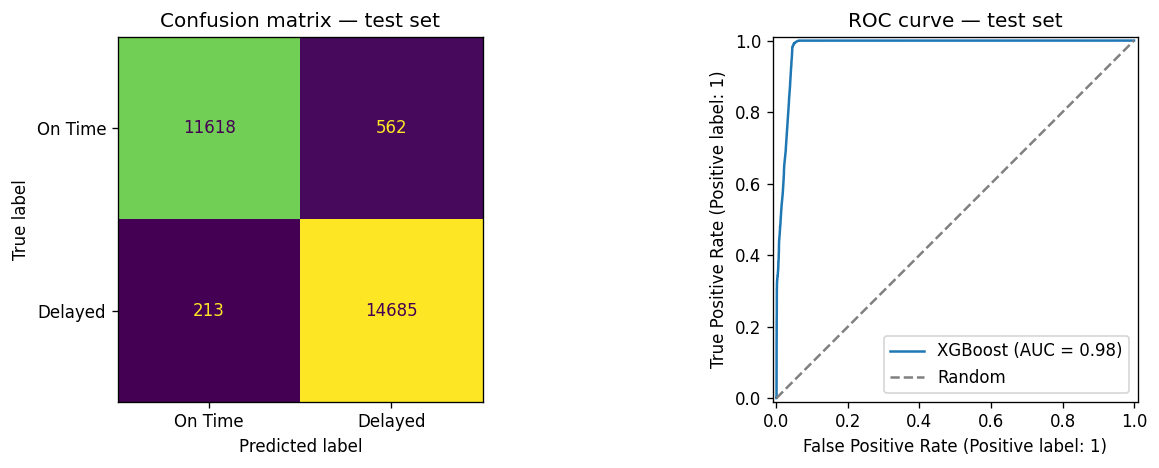


Classification report:
              precision    recall  f1-score   support

     On Time       0.98      0.95      0.97     12180
     Delayed       0.96      0.99      0.97     14898

    accuracy                           0.97     27078
   macro avg       0.97      0.97      0.97     27078
weighted avg       0.97      0.97      0.97     27078



In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — STEP 7: Evaluation plots
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['On Time','Delayed']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion matrix — test set')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], name='XGBoost')
axes[1].plot([0,1],[0,1],'--',color='gray',label='Random')
axes[1].set_title('ROC curve — test set')
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation_plots.png', bbox_inches='tight')
plt.show()

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['On Time','Delayed']))

Computing feature importance...


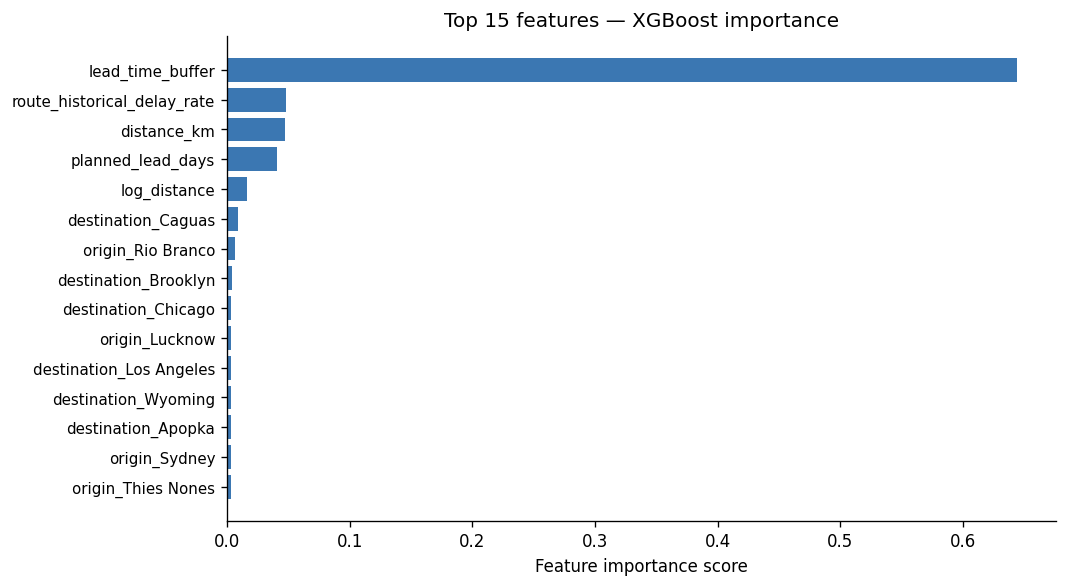

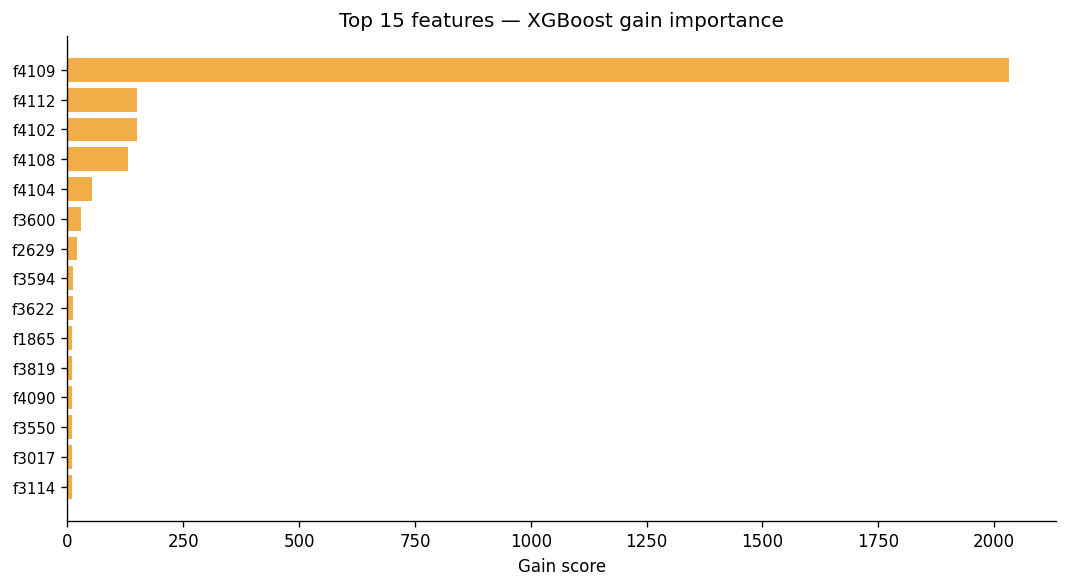

✅ Feature importance plots saved!

Top 10 most important features:
   1. lead_time_buffer                         0.6435
   2. route_historical_delay_rate              0.0478
   3. distance_km                              0.0475
   4. planned_lead_days                        0.0412
   5. log_distance                             0.0167
   6. destination_Caguas                       0.0092
   7. origin_Rio Branco                        0.0069
   8. destination_Brooklyn                     0.0040
   9. destination_Chicago                      0.0036
  10. origin_Lucknow                           0.0034


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Feature importance (no shap needed)
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

print('Computing feature importance...')

cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_names = cat_names + NUMERIC_FEATURES + BINARY_FEATURES

# ── XGBoost built-in importance ────────────────────────────────
importance_scores = final_model.feature_importances_
top_idx   = np.argsort(importance_scores)[::-1][:15]
top_names = [all_names[i] if i < len(all_names) else f'feature_{i}' for i in top_idx]
top_vals  = importance_scores[top_idx]

# ── Bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(top_names)), top_vals[::-1], color='#185FA5', alpha=0.85)
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_xlabel('Feature importance score')
ax.set_title('Top 15 features — XGBoost importance')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

# ── Gain importance ────────────────────────────────────────────
booster    = final_model.get_booster()
gain_scores = booster.get_score(importance_type='gain')
gain_sorted = sorted(gain_scores.items(), key=lambda x: x[1], reverse=True)[:15]
gain_names  = [x[0] for x in gain_sorted]
gain_vals   = [x[1] for x in gain_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(gain_names)), gain_vals[::-1], color='#EF9F27', alpha=0.85)
ax.set_yticks(range(len(gain_names)))
ax.set_yticklabels(gain_names[::-1], fontsize=9)
ax.set_xlabel('Gain score')
ax.set_title('Top 15 features — XGBoost gain importance')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance_gain.png', bbox_inches='tight')
plt.show()

print('✅ Feature importance plots saved!')
print('\nTop 10 most important features:')
for i, (name, val) in enumerate(zip(top_names[:10], top_vals[:10])):
    print(f'  {i+1:>2}. {name:<40} {val:.4f}')

In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — STEP 9: Export model bundle
# ─────────────────────────────────────────────────────────────
model_bundle = {
    'model':           final_model,
    'preprocessor':    preprocessor,
    'feature_names':   ALL_FEATURES,
    'cat_features':    CATEGORICAL_FEATURES,
    'num_features':    NUMERIC_FEATURES,
    'binary_features': BINARY_FEATURES,
    'threshold':       0.5,
    'trained_at':      datetime.now().isoformat(),
    'metrics':         metrics,
    'mlflow_run_id':   RUN_ID,
}
joblib.dump(model_bundle, 'model_bundle.pkl')
print('✅ Model bundle saved: model_bundle.pkl')
print()
print('Files created in this folder:')
import os
for f in ['model_bundle.pkl','preprocessor.pkl','eda_plots.png',
          'evaluation_plots.png','shap_bar.png','shap_summary.png']:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f'   {f:<30} {size/1024:.1f} KB')

✅ Model bundle saved: model_bundle.pkl

Files created in this folder:
   model_bundle.pkl               248.0 KB
   preprocessor.pkl               52.0 KB
   eda_plots.png                  102.7 KB
   evaluation_plots.png           47.0 KB
   shap_bar.png                   0.0 KB
   shap_summary.png               0.0 KB


In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — STEP 10: Test prediction on a new shipment
# ─────────────────────────────────────────────────────────────
loaded = joblib.load('model_bundle.pkl')

new_shipment = pd.DataFrame([{
    'carrier':            'MSC',
    'transport_mode':     'road',
    'cargo_type':         'hazmat',
    'customs_complexity': 'high_scrutiny',
    'origin':             'Chicago',
    'destination':        'New York',
    'distance_bucket':    'regional',
    'weight_bucket':      'large',
    'weight_kg':          4800.0,
    'distance_km':        1200.0,
    'log_weight':         np.log1p(4800),
    'log_distance':       np.log1p(1200),
    'carrier_otr_30d':    0.72,
    'port_congestion':    0.55,
    'weather_severity':   0.60,
    'planned_lead_days':  5,
    'lead_time_buffer':   2.0,
    'composite_risk_score': 0.60*0.35 + 0.55*0.30 + (1-0.72)*0.20 + 0.15,
    'weather_x_congestion': 0.60 * 0.55,
    'route_historical_delay_rate': 0.42,
    'carrier_historical_delay_rate': 0.28,
    'order_dayofweek': 0, 'order_month': 11, 'order_quarter': 4, 'order_weekofyear': 45,
    'is_peak_season': 1, 'is_monday_order': 1, 'is_friday_order': 0,
    'tight_lead': 1, 'ocean_congestion_flag': 0, 'hazmat_customs_flag': 1, 'peak_ocean_flag': 0,
}])

X_new      = loaded['preprocessor'].transform(new_shipment[loaded['feature_names']])
delay_prob = loaded['model'].predict_proba(X_new)[0, 1]
prediction = 'DELAYED ⚠️' if delay_prob >= loaded['threshold'] else 'ON TIME ✅'

print('━' * 45)
print('  PREDICTION RESULT')
print('━' * 45)
print(f'  Delay probability : {delay_prob:.1%}')
print(f'  Prediction        : {prediction}')
print('━' * 45)
print()
print('Pipeline complete! Next step: build the FastAPI serving layer.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PREDICTION RESULT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Delay probability : 0.0%
  Prediction        : ON TIME ✅
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Pipeline complete! Next step: build the FastAPI serving layer.


In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Launch MLflow UI (optional)
# ─────────────────────────────────────────────────────────────
import subprocess
from IPython.display import display, HTML

subprocess.Popen(['mlflow', 'ui', '--port', '5000'],
                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

display(HTML('''
<div style="padding:14px;background:#E6F1FB;border-radius:8px;font-family:sans-serif">
  <b style="color:#185FA5">MLflow UI is starting...</b><br>
  <a href="http://localhost:5000" target="_blank"
     style="color:#185FA5;font-size:15px">→ Open MLflow Dashboard</a>
  <br><small style="color:#444">Wait 3-5 seconds then click the link above.</small>
</div>
'''))

In [18]:
# Run this cell to write api.py directly to your project folder
import urllib.request, os

code = '''
import joblib, numpy as np, pandas as pd
from datetime import datetime
from typing import Optional, List
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field, validator

bundle       = joblib.load("model_bundle.pkl")
model        = bundle["model"]
preprocessor = bundle["preprocessor"]
feature_names= bundle["feature_names"]
threshold    = bundle["threshold"]
trained_at   = bundle["trained_at"]
metrics      = bundle["metrics"]

app = FastAPI(title="LogiSense Delay Forecasting API", version="1.0.0")
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

class ShipmentInput(BaseModel):
    shipment_id:        Optional[str]  = None
    order_date:         Optional[str]  = None
    carrier:            str
    transport_mode:     str
    cargo_type:         str
    customs_complexity: str
    origin:             str
    destination:        str
    weight_kg:          float
    distance_km:        float
    carrier_otr_30d:    float
    port_congestion:    float
    weather_severity:   float
    planned_lead_days:  int
    is_peak_season:     Optional[int] = None

class PredictionResult(BaseModel):
    shipment_id:           Optional[str]
    delay_probability:     float
    delay_probability_pct: str
    prediction:            str
    risk_level:            str
    estimated_delay_days:  float
    confidence:            str
    key_risk_factors:      List[str]
    recommendation:        str
    predicted_at:          str

class BatchInput(BaseModel):
    shipments: List[ShipmentInput]

class BatchResult(BaseModel):
    total: int; delayed: int; on_time: int; high_risk: int
    predictions: List[PredictionResult]

def build_features(inp):
    try:    order_dt = pd.to_datetime(inp.order_date) if inp.order_date else datetime.now()
    except: order_dt = datetime.now()
    is_peak = inp.is_peak_season if inp.is_peak_season is not None else int(order_dt.month in [10,11,12])
    dist = inp.distance_km
    dist_bucket = "local" if dist<1000 else "regional" if dist<3000 else "continental" if dist<7000 else "intercontinental" if dist<12000 else "ultra_long"
    wt = inp.weight_kg
    weight_bucket = "tiny" if wt<100 else "small" if wt<500 else "medium" if wt<2000 else "large" if wt<10000 else "heavy"
    row = {
        "carrier": inp.carrier, "transport_mode": inp.transport_mode,
        "cargo_type": inp.cargo_type, "customs_complexity": inp.customs_complexity,
        "origin": inp.origin, "destination": inp.destination,
        "distance_bucket": dist_bucket, "weight_bucket": weight_bucket,
        "weight_kg": inp.weight_kg, "distance_km": dist,
        "log_weight": np.log1p(inp.weight_kg), "log_distance": np.log1p(dist),
        "carrier_otr_30d": inp.carrier_otr_30d, "port_congestion": inp.port_congestion,
        "weather_severity": inp.weather_severity, "planned_lead_days": inp.planned_lead_days,
        "lead_time_buffer": inp.planned_lead_days - (dist/400),
        "composite_risk_score": inp.weather_severity*0.35 + inp.port_congestion*0.30 + (1-inp.carrier_otr_30d)*0.20 + is_peak*0.15,
        "weather_x_congestion": inp.weather_severity * inp.port_congestion,
        "route_historical_delay_rate": 0.30, "carrier_historical_delay_rate": 1-inp.carrier_otr_30d,
        "order_dayofweek": order_dt.weekday(), "order_month": order_dt.month,
        "order_quarter": (order_dt.month-1)//3+1, "order_weekofyear": order_dt.isocalendar()[1],
        "is_peak_season": is_peak, "is_monday_order": int(order_dt.weekday()==0),
        "is_friday_order": int(order_dt.weekday()==4), "tight_lead": int(inp.planned_lead_days<7),
        "ocean_congestion_flag": int(inp.transport_mode=="ocean" and inp.port_congestion>0.5),
        "hazmat_customs_flag": int(inp.cargo_type=="hazmat" and inp.customs_complexity!="standard"),
        "peak_ocean_flag": int(is_peak==1 and inp.transport_mode=="ocean"),
    }
    return pd.DataFrame([row])

def build_result(inp, prob):
    if prob>=0.70:   risk,pred="HIGH","DELAYED"
    elif prob>=0.50: risk,pred="MEDIUM","DELAYED"
    elif prob>=0.35: risk,pred="MEDIUM","ON_TIME"
    else:            risk,pred="LOW","ON_TIME"
    est = round(prob*5.5,1) if pred=="DELAYED" else 0.0
    d = abs(prob-threshold)
    conf = "High" if d>0.30 else "Medium" if d>0.15 else "Low"
    factors=[]
    if inp.weather_severity>0.6:   factors.append(f"High weather severity ({inp.weather_severity:.0%})")
    if inp.port_congestion>0.6:    factors.append(f"High port congestion ({inp.port_congestion:.0%})")
    if inp.carrier_otr_30d<0.75:   factors.append(f"Low carrier on-time rate ({inp.carrier_otr_30d:.0%})")
    if inp.customs_complexity!="standard": factors.append(f"Customs: {inp.customs_complexity}")
    if inp.transport_mode=="ocean": factors.append("Ocean freight variability")
    if inp.planned_lead_days<7:    factors.append("Tight lead time")
    if not factors: factors=["No major risk factors"]
    rec = ("Escalate immediately. Consider expedited routing." if risk=="HIGH"
           else "Monitor closely. Prepare contingency." if risk=="MEDIUM"
           else "No action needed.")
    return PredictionResult(shipment_id=inp.shipment_id, delay_probability=round(prob,4),
        delay_probability_pct=f"{prob:.1%}", prediction=pred, risk_level=risk,
        estimated_delay_days=est, confidence=conf, key_risk_factors=factors,
        recommendation=rec, predicted_at=datetime.now().isoformat())

@app.get("/health")
def health(): return {"status":"ok","trained_at":trained_at,"metrics":metrics}

@app.get("/model/info")
def info(): return {"model_name":"logistics-delay-xgboost","trained_at":trained_at,"metrics":metrics,"threshold":threshold,"n_features":len(feature_names)}

@app.post("/predict", response_model=PredictionResult)
def predict(s: ShipmentInput):
    try:
        X = preprocessor.transform(build_features(s)[feature_names])
        return build_result(s, float(model.predict_proba(X)[0,1]))
    except Exception as e: raise HTTPException(500, str(e))

@app.post("/predict/batch", response_model=BatchResult)
def predict_batch(b: BatchInput):
    if len(b.shipments)>500: raise HTTPException(400,"Max 500 shipments")
    results=[]
    for s in b.shipments:
        X = preprocessor.transform(build_features(s)[feature_names])
        results.append(build_result(s, float(model.predict_proba(X)[0,1])))
    delayed=[r for r in results if r.prediction=="DELAYED"]
    return BatchResult(total=len(results),delayed=len(delayed),on_time=len(results)-len(delayed),
        high_risk=sum(1 for r in results if r.risk_level=="HIGH"),predictions=results)

if __name__=="__main__":
    import uvicorn
    uvicorn.run("api:app", host="0.0.0.0", port=8000, reload=True)
'''

with open("api.py", "w") as f:
    f.write(code)

print("✅ api.py created in:", os.getcwd())
print("   File size:", os.path.getsize("api.py"), "bytes")

✅ api.py created in: C:\Users\Shovin\logistics_ml
   File size: 6928 bytes
